# 📊 Exploration — SP500 | GOLD | BRENT | EURUSD
Données M5 récupérées via MetaTrader5 (Admirals)

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from pathlib import Path


%matplotlib inline
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['figure.dpi'] = 120
sns.set_theme(style='darkgrid')

ModuleNotFoundError: No module named 'scipy'

In [4]:
DATA_DIR = Path('../SCR/data')

sp500 = pd.read_csv(DATA_DIR / 'sp500_m5.csv',  index_col='time', parse_dates=True)
gold  = pd.read_csv(DATA_DIR / 'or_m5.csv',     index_col='time', parse_dates=True)
brent = pd.read_csv(DATA_DIR / 'brent_m5.csv',  index_col='time', parse_dates=True)
eurusd= pd.read_csv(DATA_DIR / 'eurusd_m5.csv', index_col='time', parse_dates=True)

datasets = {
    'SP500':  sp500,
    'GOLD':   gold,
    'BRENT':  brent,
    'EURUSD': eurusd
}

In [9]:
sp500.head()

,open,high,low,close,tick_volume
time,,,,,
2024-11-14 15:20:00+00:00,5995.33,5995.71,5994.22,5995.50,105
2024-11-14 15:25:00+00:00,5995.74,5996.00,5994.49,5995.73,100
2024-11-14 15:30:00+00:00,5995.48,5995.85,5985.72,5986.59,494
2024-11-14 15:35:00+00:00,5986.71,5988.46,5981.72,5985.08,404
2024-11-14 15:40:00+00:00,5985.45,5992.08,5985.44,5989.95,313


In [8]:
sp500.isna().sum()

open           0
high           0
low            0
close          0
tick_volume    0
dtype: int64

In [6]:
sp500.describe()

,open,high,low,close,tick_volume
count,99999.000000,99999.000000,99999.000000,99999.000000,99999.000000
mean,6318.340061,6320.451160,6316.191595,6318.354737,228.517625
std,472.580599,472.170771,473.006940,472.581445,213.215357
min,4815.030000,4828.400000,4804.280000,4813.530000,1.000000
25%,5964.990000,5966.630000,5962.865000,5964.935000,71.000000
50%,6366.780000,6368.200000,6365.030000,6366.860000,154.000000
75%,6763.610000,6766.345000,6761.480000,6763.580000,319.000000
max,7149.760000,7151.760000,7149.510000,7150.010000,1876.000000


<Axes: xlabel='time', ylabel='close'>

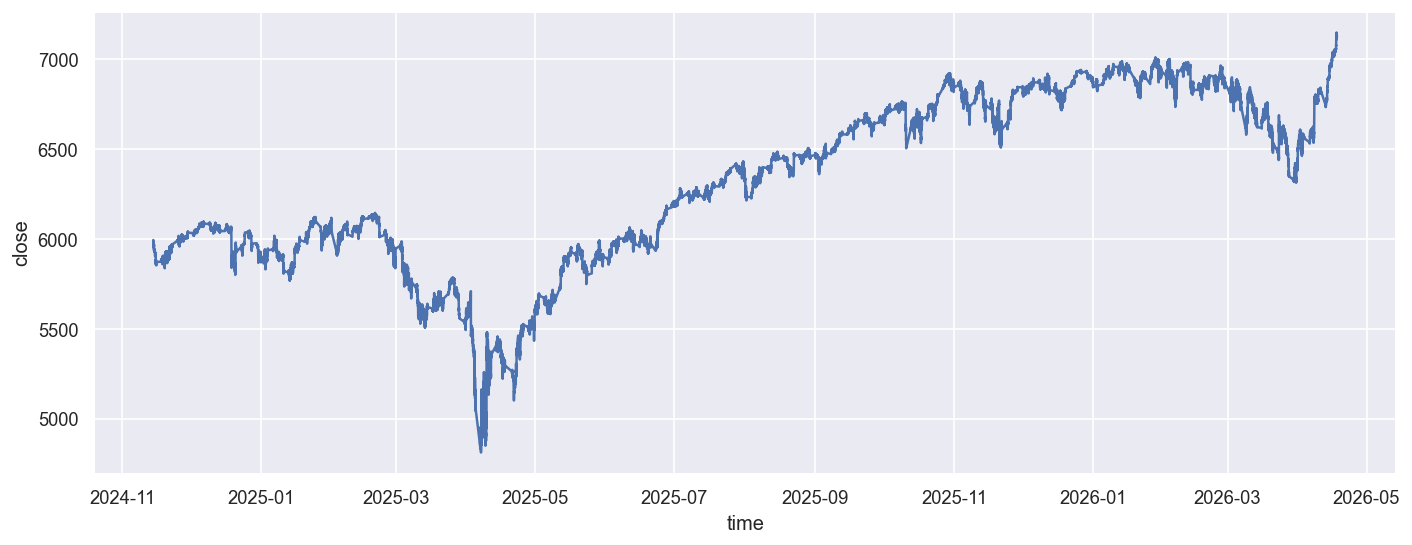

In [10]:
sns.lineplot(data=sp500,x="time",y="close")


In [11]:
# Calcul du rendement en log brut
sp500['log_return'] = np.log(sp500['close'] / sp500['close'].shift(1))

In [12]:
# Statistiques descriptives
r = sp500['log_return'].dropna()
pd.DataFrame([{
    'Moyenne':  round(r.mean(), 6),
    'Std':      round(r.std(), 6),
    'Min':      round(r.min(), 4),
    'Max':      round(r.max(), 4),
    'Skewness': round(r.skew(), 4),
    'Kurtosis': round(r.kurtosis(), 4),
}])

,Moyenne,Std,Min,Max,Skewness,Kurtosis
0,0.000002,0.000692,-0.0427,0.039,0.2817,393.6363


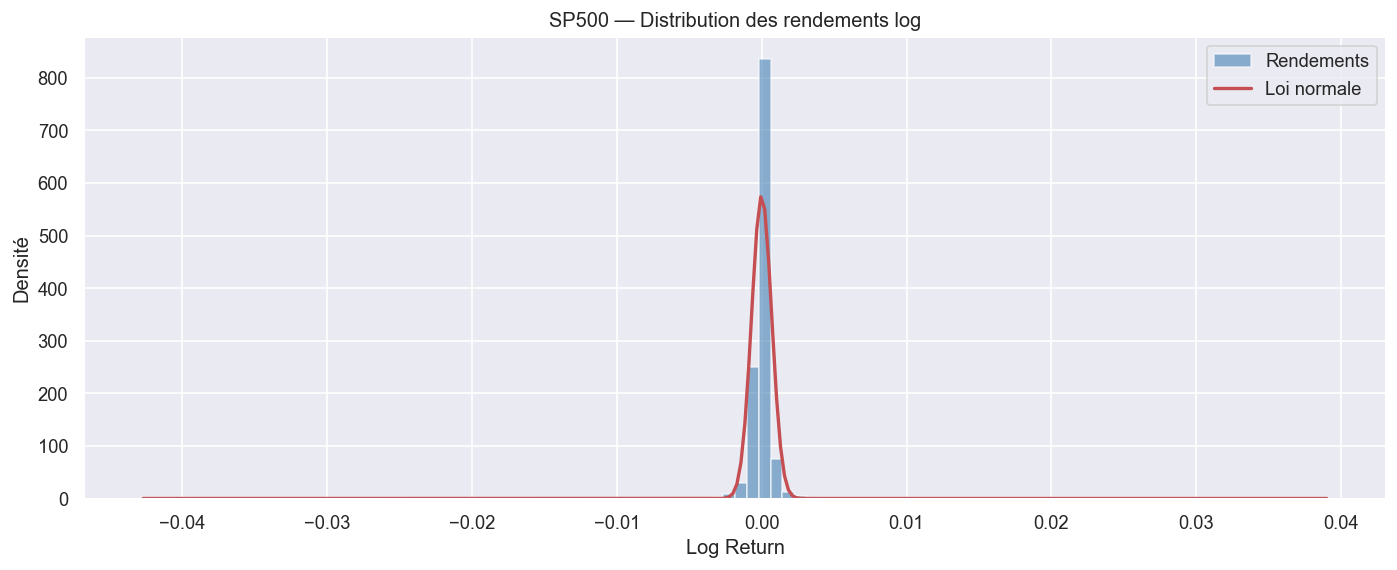

In [25]:
# Distribution vs loi normale
r = sp500['log_return'].dropna()
plt.figure()
plt.hist(r, bins=100, density=True, alpha=0.6, color='steelblue', label='Rendements')

# Courbe normale manuelle sans scipy
x = np.linspace(r.min(), r.max(), 300)
normale = (1 / (r.std() * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x - r.mean()) / r.std()) ** 2)
plt.plot(x, normale, 'r-', lw=2, label='Loi normale')

plt.title('SP500 — Distribution des rendements log')
plt.xlabel('Log Return')
plt.ylabel('Densité')
plt.legend()
plt.show()

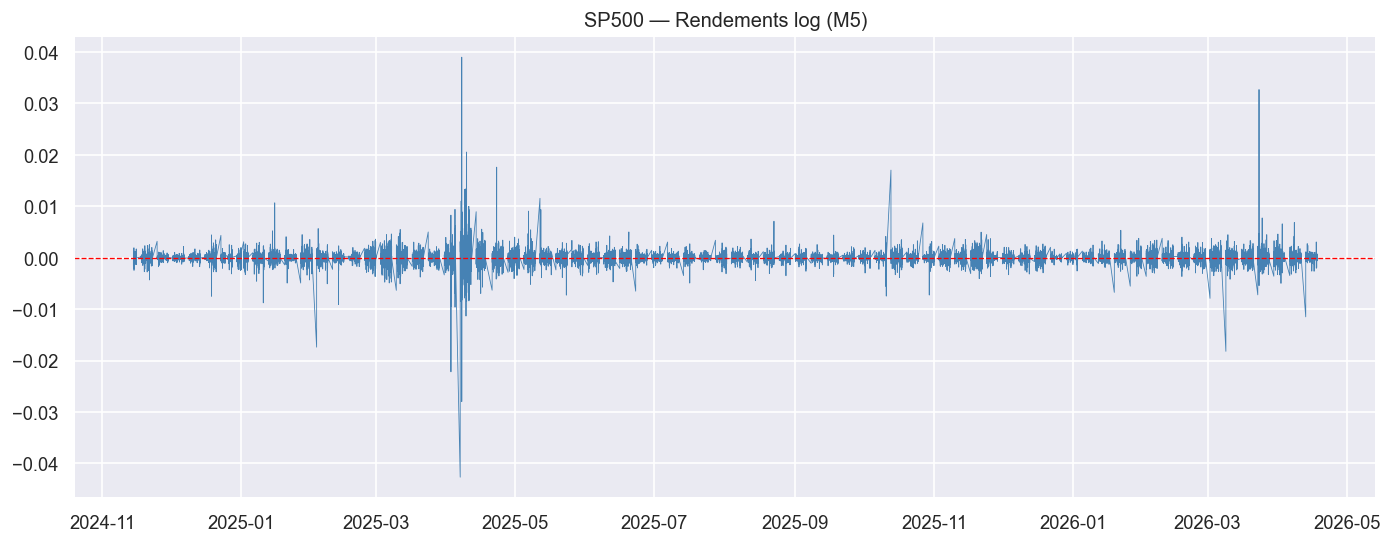

In [26]:
# Évolution dans le temps
plt.figure()
plt.plot(sp500['log_return'], lw=0.5, color='steelblue')
plt.axhline(0, color='red', lw=0.8, linestyle='--')
plt.title('SP500 — Rendements log (M5)')
plt.show()

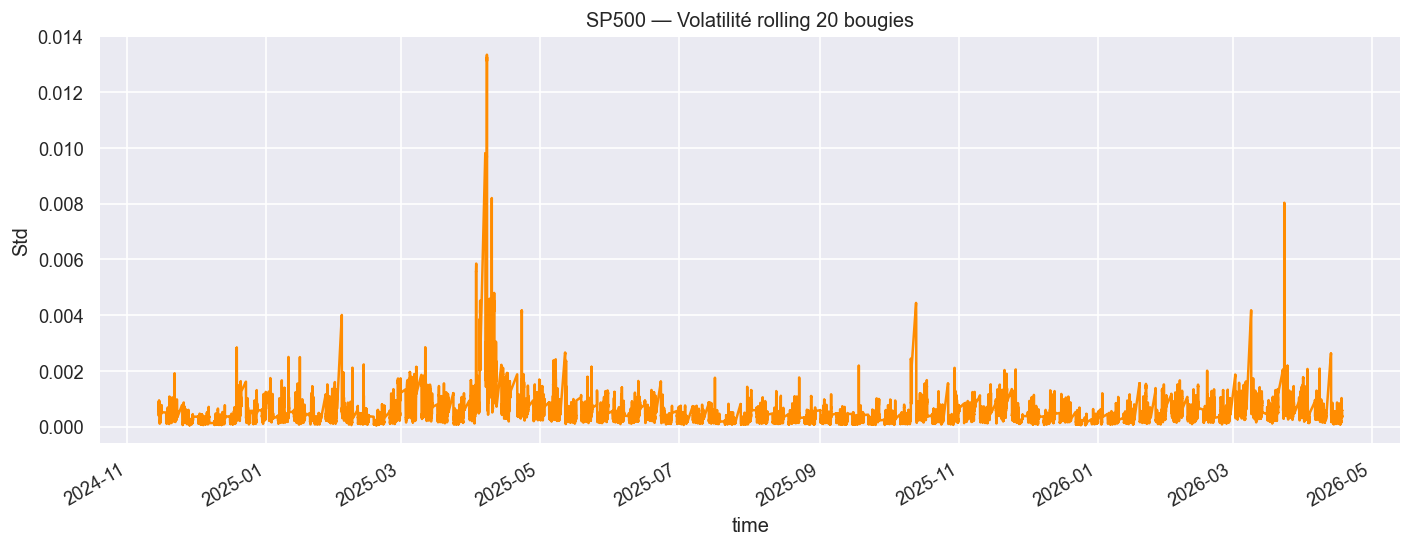

In [27]:
# Volatilité rolling 20 bougies
plt.figure()
sp500['log_return'].rolling(20).std().plot(color='darkorange')
plt.title('SP500 — Volatilité rolling 20 bougies')
plt.ylabel('Std')
plt.show()

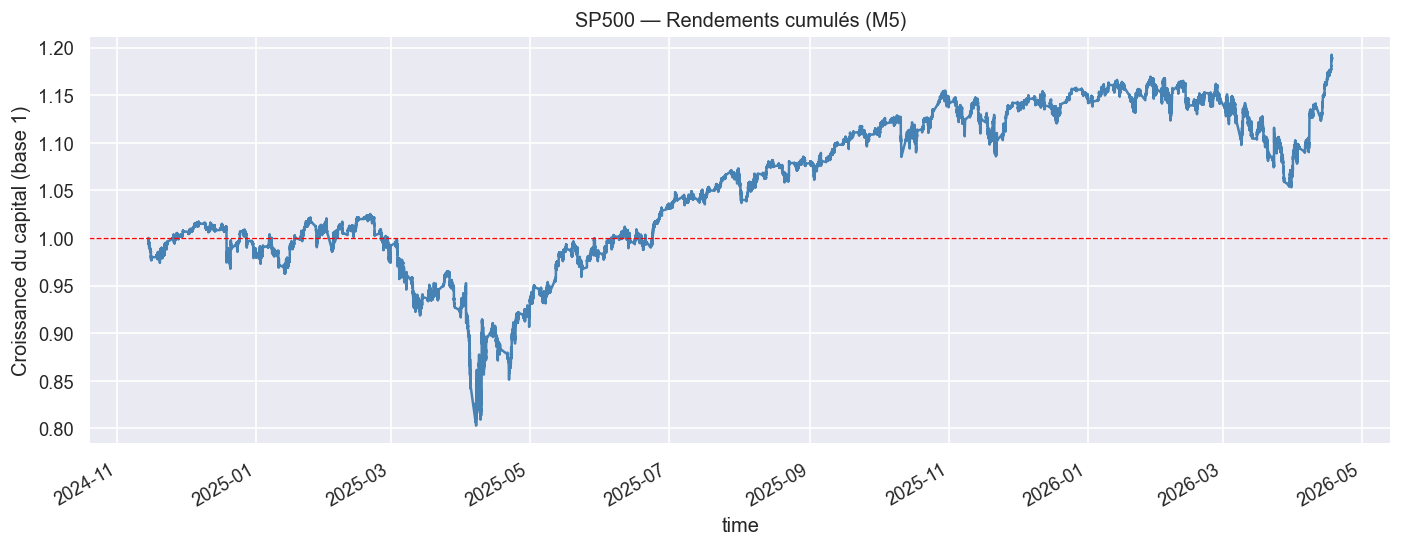

In [29]:
# Rendements cumulés (méthode correcte pour les log returns)
rendements_cumules = np.exp(sp500['log_return'].dropna().cumsum())

plt.figure()
rendements_cumules.plot(color='steelblue')
plt.title('SP500 — Rendements cumulés (M5)')
plt.ylabel('Croissance du capital (base 1)')
plt.axhline(1, color='red', lw=0.8, linestyle='--')
plt.show()

In [ ]:
"re"

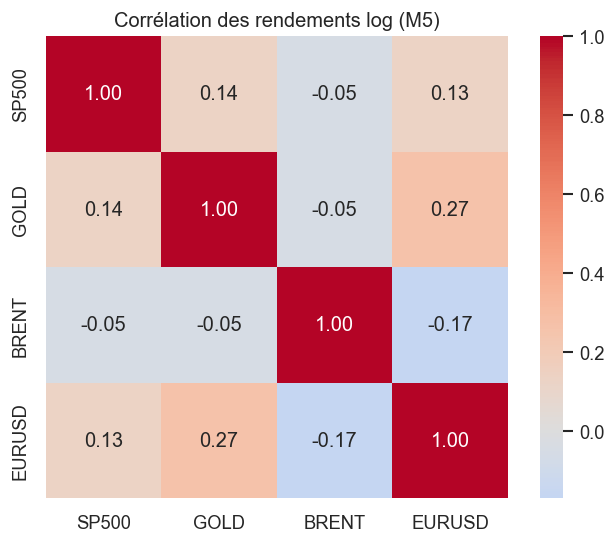

In [30]:
# Alignement des closes sur le même index
df_close = pd.DataFrame({
    'SP500':  sp500['close'],
    'GOLD':   gold['close'],
    'BRENT':  brent['close'],
    'EURUSD': eurusd['close']
}).dropna()

# Calcul des log returns pour chaque actif
df_returns = np.log(df_close / df_close.shift(1)).dropna()

# Heatmap
plt.figure(figsize=(7, 5))
sns.heatmap(df_returns.corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True)
plt.title('Corrélation des rendements log (M5)')
plt.show()